# Flood Prediction Results Visualization

This notebook visualizes the saved results for the persistence baseline, Random Forest, and LSTM models. It reads artifacts from the `results/` directory so figures stay tied to the reproducible training scripts.

## Setup

In [8]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
RESULTS_DIR = PROJECT_ROOT / "results"

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

RESULTS_DIR

WindowsPath('C:/Users/davee/Desktop/projects/flood prediction revise/Flood-Prediction/results')

## Metrics Summary

In [9]:
metrics_path = RESULTS_DIR / "metrics.json"

with metrics_path.open("r", encoding="utf-8") as file:
    metrics = json.load(file)

metrics_df = pd.DataFrame(metrics).T
metric_cols = [col for col in ["rmse", "mae", "r2", "nse"] if col in metrics_df.columns]
metrics_df = metrics_df.sort_values("rmse")

display(metrics_df[metric_cols])

,rmse,mae,r2,nse
lstm,0.3902,0.2330,0.9843,0.9843
random_forest,1.7780,1.2204,0.6479,0.6479
persistence_baseline,1.9988,1.2578,0.5550,0.5550


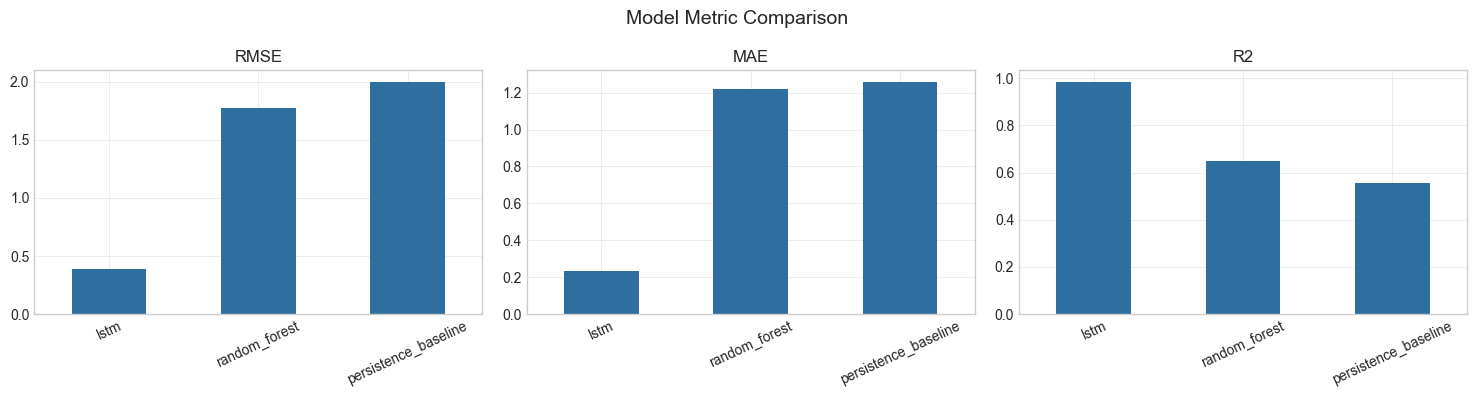

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, title in zip(axes, ["rmse", "mae", "r2"], ["RMSE", "MAE", "R2"]):
    if metric not in metrics_df.columns:
        ax.axis("off")
        continue
    metrics_df[metric].plot(kind="bar", ax=ax, color="#2f6f9f")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)

fig.suptitle("Model Metric Comparison", fontsize=14)
fig.tight_layout()
plt.show()

## Actual vs Predicted Discharge

The baseline and Random Forest scripts save prediction CSVs. The LSTM script also saves `lstm_predictions.csv` after it is run. If that CSV is not present, this notebook displays the saved LSTM plot instead.

In [11]:
prediction_files = {
    "Persistence baseline": RESULTS_DIR / "baseline_predictions.csv",
    "Random Forest": RESULTS_DIR / "random_forest_predictions.csv",
    "LSTM": RESULTS_DIR / "lstm_predictions.csv",
}

prediction_frames = {}
for model_name, path in prediction_files.items():
    if path.exists():
        prediction_frames[model_name] = pd.read_csv(path)
    else:
        display(Markdown(f"Prediction CSV not found for **{model_name}**: `{path.name}`"))

list(prediction_frames)

['Persistence baseline', 'Random Forest', 'LSTM']

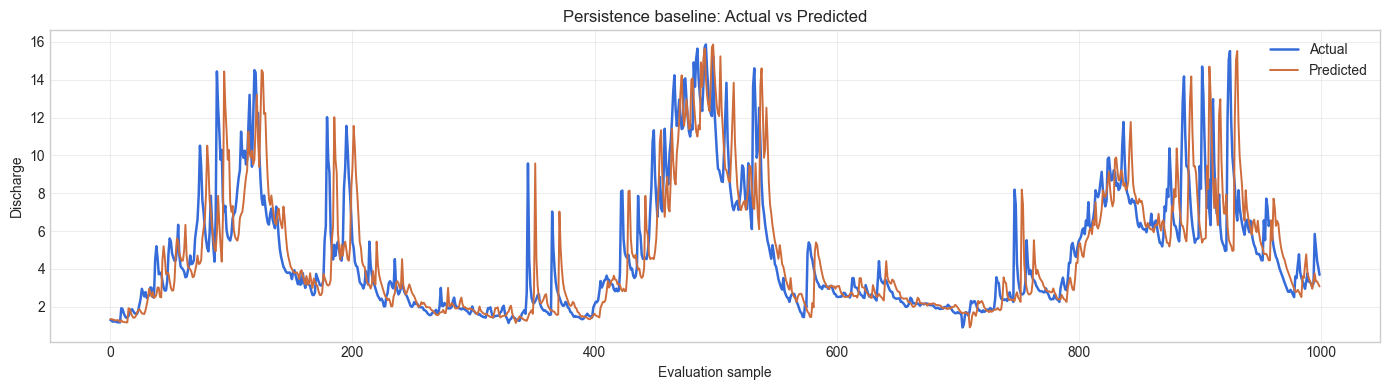

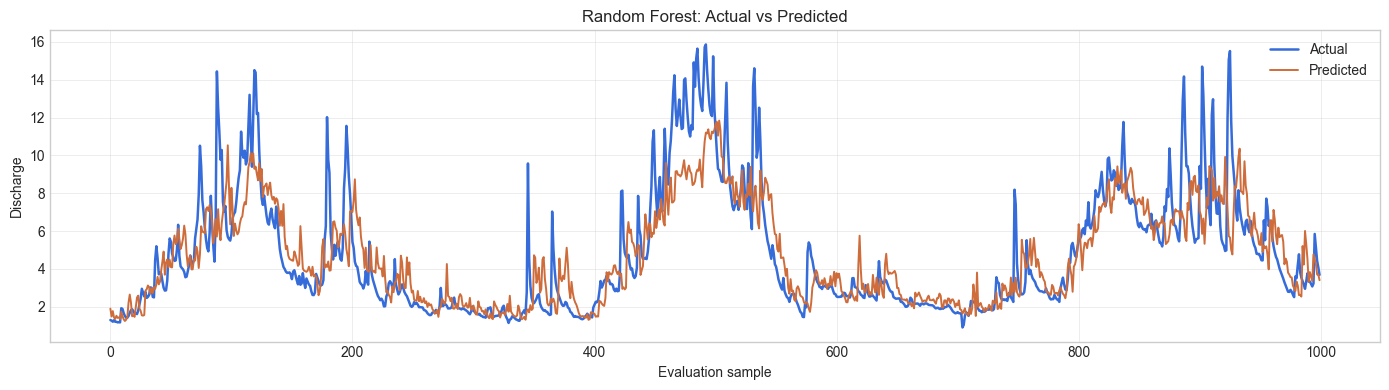

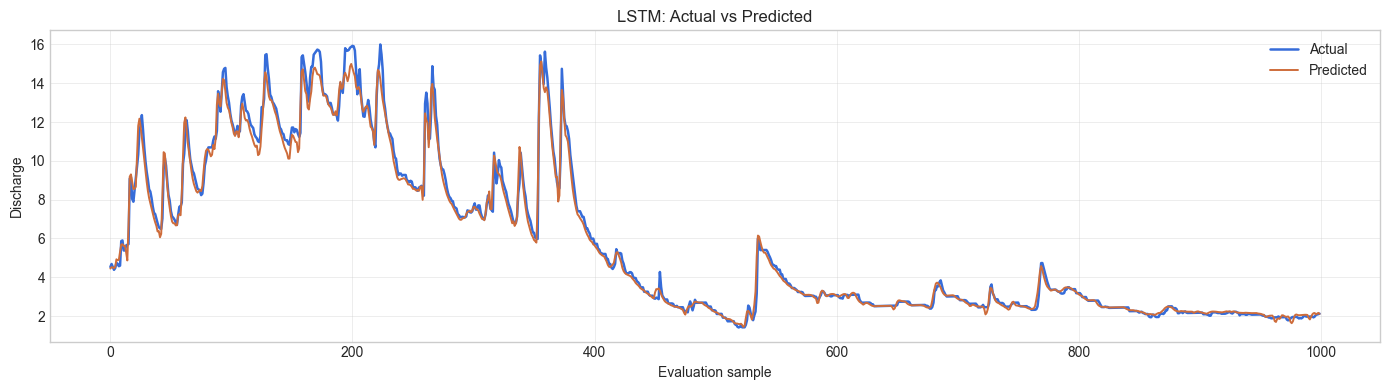

In [12]:
for model_name, frame in prediction_frames.items():
    fig, ax = plt.subplots(figsize=(14, 4))
    plot_frame = frame.iloc[:1000]
    ax.plot(plot_frame["actual"].to_numpy(), label="Actual", linewidth=1.8)
    ax.plot(plot_frame["predicted"].to_numpy(), label="Predicted", linewidth=1.4)
    ax.set_title(f"{model_name}: Actual vs Predicted")
    ax.set_xlabel("Evaluation sample")
    ax.set_ylabel("Discharge")
    ax.legend()
    fig.tight_layout()
    plt.show()

if "LSTM" not in prediction_frames:
    lstm_plot = RESULTS_DIR / "lstm_actual_vs_predicted.png"
    if lstm_plot.exists():
        display(Markdown("### LSTM: saved actual-vs-predicted plot"))
        display(Image(filename=str(lstm_plot)))

## Residual Analysis

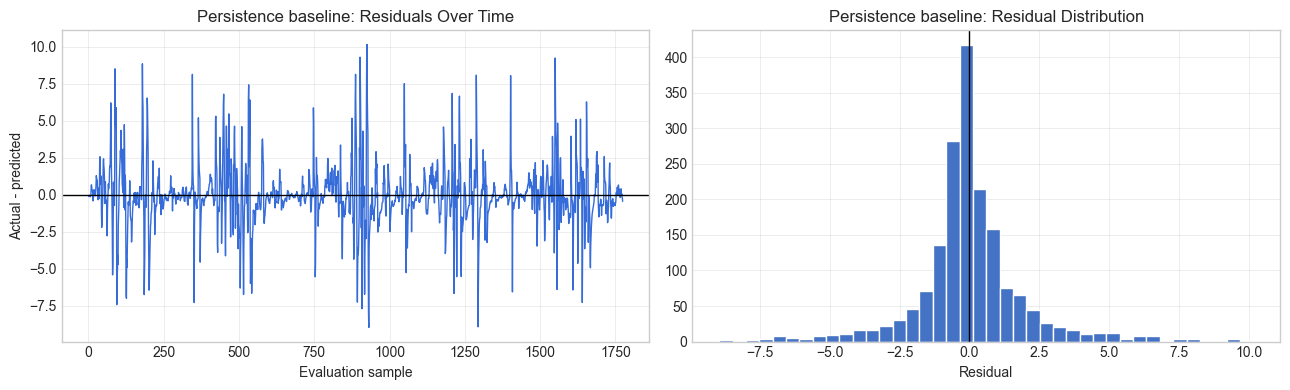

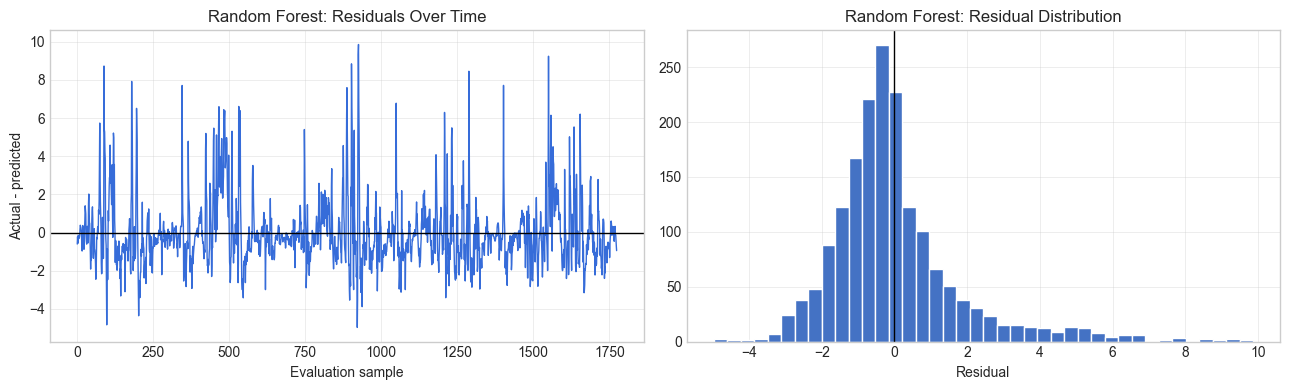

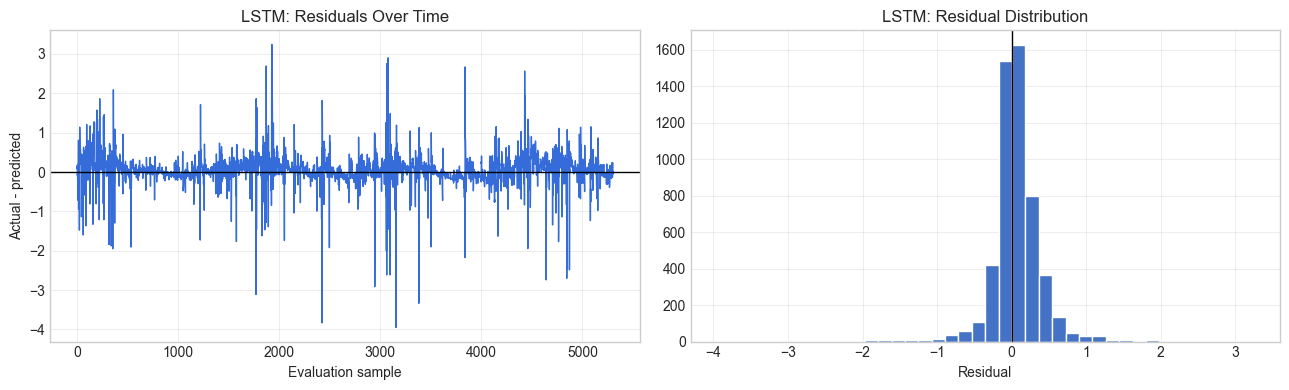

In [13]:
for model_name, frame in prediction_frames.items():
    residual = frame["actual"] - frame["predicted"]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(residual.to_numpy(), linewidth=1)
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title(f"{model_name}: Residuals Over Time")
    axes[0].set_xlabel("Evaluation sample")
    axes[0].set_ylabel("Actual - predicted")

    axes[1].hist(residual, bins=40, color="#4472c4", edgecolor="white")
    axes[1].axvline(0, color="black", linewidth=1)
    axes[1].set_title(f"{model_name}: Residual Distribution")
    axes[1].set_xlabel("Residual")

    fig.tight_layout()
    plt.show()

## Random Forest Feature Importance

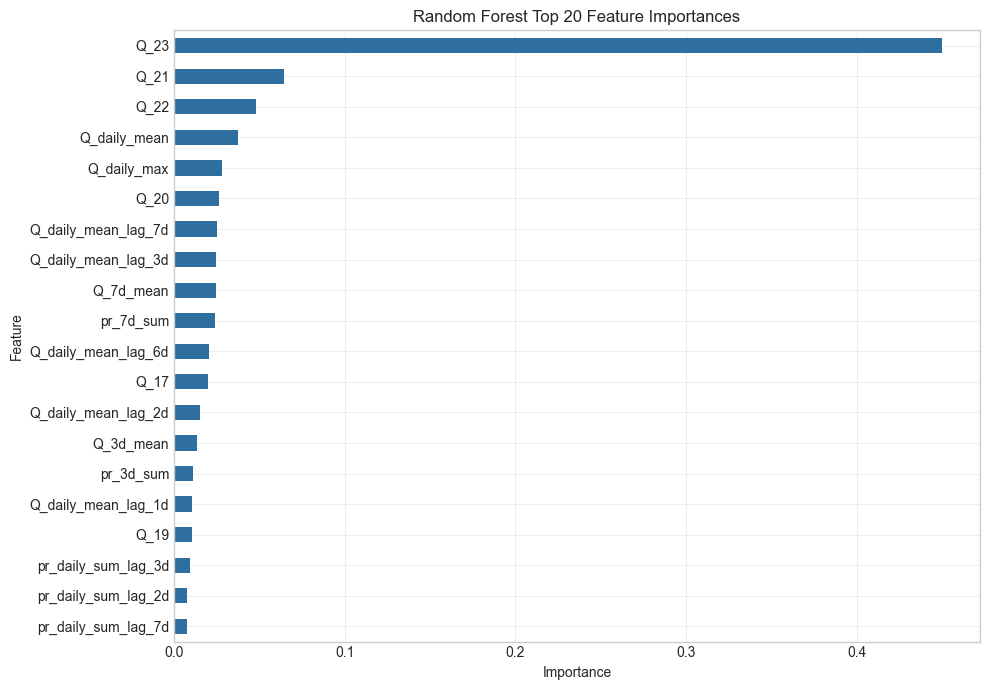

In [14]:
importance_path = RESULTS_DIR / "random_forest_feature_importance.csv"

if importance_path.exists():
    importance = pd.read_csv(importance_path, index_col=0).head(20).sort_values("importance")
    ax = importance.plot(kind="barh", figsize=(10, 7), legend=False, color="#2f6f9f")
    ax.set_title("Random Forest Top 20 Feature Importances")
    ax.set_xlabel("Importance")
    ax.set_ylabel("Feature")
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("Random Forest feature importance file is not available yet."))

## Regenerating Results

Run these commands from the project root if any artifacts are missing:

```bash
python src/train_random_forest.py
python src/train_lstm.py
python src/evaluate.py
```

For a quick LSTM smoke test, use `python src/train_lstm.py --epochs 1`. For final LSTM metrics, run the full training command.